# 🏨 Análisis de Reseñas de Hoteles

Este notebook tiene como objetivo analizar reseñas de una cadena hotelera aplicando técnicas de procesamiento de lenguaje natural. Se exploran métodos clásicos como limpieza de texto, TF-IDF, análisis sintáctico y un modelo de clasificación de sentimiento.

---


## 1. 🧹 Preprocesamiento de Texto

En esta sección se realiza:
- Conversión a minúsculas
- Eliminación de signos de puntuación
- Eliminación de stopwords en español


In [1]:
!python -m spacy download es_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 8.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import pandas as pd
import re
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [3]:
# Descargar recursos
nltk.download("stopwords")
nltk.download('punkt_tab')
nlp = spacy.load("es_core_news_md")

# Stopwords y función de limpieza
stopwords_es = set(stopwords.words('spanish'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
path = '/content/drive/MyDrive/2025-2/NLP/Big_AHR.csv'
df_reviews = pd.read_csv(path, index_col='Unnamed: 0')
df_reviews.head()

,title,rating,review_text,location,hotel,label
0,Excelente y personal amable,5,Un hotel muy bueno. El personal fue muy amabl...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
1,Céntrico,4,"Muy buen hotel al nivel de lo esperado, habita...",Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
2,Hotel excepcional,5,Magnífico hotel. La verdad es que todo perfect...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
3,WOW!!,5,"Hotel hermoso, buen diseño, original, limpio. ...",Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
4,Magnifico,5,Magnífica ubicación en pleno centro de Sevilla...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1


In [6]:
def preprocess(text: str) -> str:
    """
    Clean a given text string by removing punctuation, converting to lowercase,
    filtering out Spanish stopwords and lemmatizing.

    Parameters
    ----------
    text : str
        The original input text to be processed.

    Returns
    -------
    str
        The cleaned text string.
    """
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text, flags=re.UNICODE)
    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token not in stopwords_es]
    doc = nlp(" ".join(tokens))
    tokens = [token.lemma_ for token in doc]

    return " ".join(tokens)

## 2. 🧾 Unificación del Texto

Se combinan las columnas `title` y `review_text` para tener un campo de análisis completo y luego se aplica la limpieza textual.


In [7]:
df_reviews["full_review"] = df_reviews["title"] + ". " + df_reviews["review_text"]
df_reviews["clean_text"] = df_reviews["full_review"].apply(preprocess)
df_reviews

,title,rating,review_text,location,hotel,label,full_review,clean_text
0,Excelente y personal amable,5,Un hotel muy bueno. El personal fue muy amabl...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1,Excelente y personal amable. Un hotel muy buen...,excelente personal amable hotel bueno personal...
1,Céntrico,4,"Muy buen hotel al nivel de lo esperado, habita...",Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1,Céntrico. Muy buen hotel al nivel de lo espera...,céntrico buen hotel nivel esperado habitación ...
2,Hotel excepcional,5,Magnífico hotel. La verdad es que todo perfect...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1,Hotel excepcional. Magnífico hotel. La verdad ...,hotel excepcional magnífico hotel verdad perfe...
3,WOW!!,5,"Hotel hermoso, buen diseño, original, limpio. ...",Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1,"WOW!!. Hotel hermoso, buen diseño, original, l...",wow hotel hermoso buen diseño original limpio ...
4,Magnifico,5,Magnífica ubicación en pleno centro de Sevilla...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1,Magnifico. Magnífica ubicación en pleno centro...,magnifico magnífico ubicación pleno centro sev...
...,...,...,...,...,...,...,...,...
18167,remanso de paz en el corazón de Córdoba,5,Hemos empezado el año con una estancia de tres...,NaN,NaN,1,remanso de paz en el corazón de Córdoba. Hemos...,remanso paz corazón córdoba empezar año estanc...
18168,"Oasis de paz, tranquilidad y belleza!",5,Al atravesar el umbral de la puerta que conduc...,NaN,NaN,1,"Oasis de paz, tranquilidad y belleza!. Al atra...",oasis paz tranquilidad bellezar atravesar umbr...
18169,Un lugar para recordar,5,En este hotel todo son sensaciones y experienc...,NaN,NaN,1,Un lugar para recordar. En este hotel todo son...,lugar recordar hotel sensación experiencia pos...
18170,Extraordinario,5,Hemos pasado un par de noches en este exquisit...,NaN,NaN,1,Extraordinario. Hemos pasado un par de noches ...,extraordinario pasado par noche exquisito hote...


In [9]:
df_reviews[["label","rating"]].value_counts()

label  rating
1      5         9005
       4         4222
3      3         2274
0      1         1677
       2          994
Name: count, dtype: int64

In [ ]:
df_reviews["label"] = df_reviews.label.replace(3,1)

In [ ]:
df_reviews["label"].value_counts()

,count
label,
1,15501
0,2671


## 3. 🧮 Vectorización con TF-IDF

TF-IDF (Term Frequency - Inverse Document Frequency) permite transformar texto en vectores numéricos que capturan la relevancia de las palabras en los documentos.

Aquí se seleccionan las 30 palabras más relevantes del corpus limpio.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
vectorizer = TfidfVectorizer(max_features=30)
X = vectorizer.fit_transform(df_reviews["clean_text"])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

In [ ]:
tfidf_df.head()

,amable,baño,bien,buen,cama,centro,cerca,cómodo,dar,desayuno,día,excelente,habitación,hacer,hotel,ir,limpio,lugar,mejor,noche,pequeño,perfecto,personal,poder,precio,servicio,si,ubicación,volver,él
0,0.557946,0.0,0.0,0.000000,0.000000,0.268864,0.307185,0.0,0.0,0.244621,0.0,0.276152,0.169201,0.000000,0.171505,0.0,0.246231,0.000000,0.000000,0.0,0.0,0.000000,0.444901,0.0,0.0,0.000000,0.0,0.263320,0.0,0.0
1,0.000000,0.0,0.0,0.617715,0.000000,0.000000,0.000000,0.0,0.0,0.346411,0.0,0.000000,0.239608,0.379138,0.242870,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.315015,0.0,0.0,0.000000,0.0,0.372892,0.0,0.0
2,0.370781,0.0,0.0,0.000000,0.000000,0.000000,0.408278,0.0,0.0,0.325124,0.0,0.000000,0.224884,0.000000,0.455892,0.0,0.000000,0.000000,0.401104,0.0,0.0,0.413317,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
3,0.000000,0.0,0.0,0.604627,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.382777,0.000000,0.000000,0.237724,0.0,0.341302,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.426252,0.0,0.364991,0.0,0.0
4,0.000000,0.0,0.0,0.000000,0.381974,0.371111,0.000000,0.0,0.0,0.337648,0.0,0.000000,0.233547,0.000000,0.236727,0.0,0.000000,0.418848,0.000000,0.0,0.0,0.429239,0.000000,0.0,0.0,0.000000,0.0,0.363459,0.0,0.0


**Funciones:**
```python
def func(a,b=50,*args,**kwargs):
  print(a,b,args,kwargs)
  return {'val1':a,'val2':b, 'val3':args, 'val4':kwargs}
  ```

In [ ]:
def extract_top_tfidf_words(tfidf_df: pd.DataFrame, top_n: int = 5) -> pd.DataFrame:
    """
    Extracts the top N words with the highest TF-IDF scores for each document in the input DataFrame.

    Args:
        tfidf_df (pd.DataFrame): A DataFrame where rows represent documents and columns are words,
                                 with TF-IDF scores as values.
        top_n (int, optional): Number of top words to extract per document. Default is 5.

    Returns:
        pd.DataFrame: A DataFrame with one row per document and two columns:
                      - 'Top_Words': list of the top N words
                      - 'Top_Scores': list of corresponding TF-IDF scores
    """
    top_words = []
    top_scores = []

    for _, row in tfidf_df.iterrows():
        top_items = row.sort_values(ascending=False).head(top_n)
        top_words.append(list(top_items.index))
        top_scores.append(list(top_items.values))

    return pd.DataFrame({
        "Top_Words": top_words,
        "Top_Scores": top_scores
    })

In [ ]:
top_tfidf = extract_top_tfidf_words(tfidf_df.head())
top_tfidf.Top_Scores = top_tfidf.Top_Scores.apply(lambda x: [round(score, 2) for score in x])
top_tfidf

,Top_Words,Top_Scores
0,"[amable, personal, cerca, excelente, centro]","[0.56, 0.44, 0.31, 0.28, 0.27]"
1,"[buen, hacer, ubicación, desayuno, personal]","[0.62, 0.38, 0.37, 0.35, 0.32]"
2,"[hotel, perfecto, cerca, mejor, amable]","[0.46, 0.41, 0.41, 0.4, 0.37]"
3,"[buen, servicio, excelente, ubicación, limpio]","[0.6, 0.43, 0.38, 0.36, 0.34]"
4,"[perfecto, lugar, cama, centro, ubicación]","[0.43, 0.42, 0.38, 0.37, 0.36]"


## 🔍 Interpretación por documento:
- Documento 0:   
    **Palabras destacadas**:
    amable (0.56), personal (0.44), cerca (0.31), excelente (0.28), centro (0.27)  
    **Interpretación**:
    El usuario destaca la amabilidad del personal, una experiencia excelente, y la proximidad al centro, lo que sugiere una reseña muy positiva enfocada tanto en la atención como en la ubicación.
- Documento 1  
    **Palabras destacadas**:
    buen (0.62), hacer (0.38), ubicación (0.37), desayuno (0.35), personal (0.32)  
    **Interpretación**:
    Se menciona que todo fue bueno, con énfasis en la ubicación y el desayuno, posiblemente haciendo referencia a actividades o servicios bien gestionados ("hacer"). La mención del personal refuerza la percepción positiva del servicio.
- Documento 2  
    **Palabras destacadas**:
    hotel (0.46), perfecto (0.41), cerca (0.41), mejor (0.40), amable (0.37)  
    **Interpretación**:
    Una reseña altamente satisfactoria. Se percibe como un hotel perfecto y cercano, posiblemente a sitios turísticos o de interés. Se valora como mejor opción, y se destaca nuevamente la amabilidad del personal.
- Documento 3  
    **Palabras destacadas**:
    buen (0.60), servicio (0.43), excelente (0.38), ubicación (0.36), limpio (0.34)  
    Interpretación:
    Un enfoque muy directo sobre la calidad del servicio, el cual fue bueno, excelente y limpio. Se valora también la ubicación, por lo que esta reseña refuerza puntos clave de atención al cliente.
- Documento 4  
    **Palabras destacadas**:
    perfecto (0.43), lugar (0.42), cama (0.38), centro (0.37), ubicación (0.36)  
    **Interpretación**:
    El enfoque está en lo perfecto del lugar, y resalta el confort de la cama y la ubicación céntrica. Este tipo de reseñas ayuda al hotel a entender que el confort físico y la ubicación son elementos diferenciadores.



#### 📊 Conclusión general
El TF-IDF ayuda a identificar qué aspectos resaltan más por reseña:

Palabras comunes como "hotel" aparecen en todos, pero su peso es menor en algunos documentos.

Palabras distintivas como amable, trato, limpio, excelente, aparecen con alto peso cuando destacan en una reseña específica.

## 4. ☁️ Nubes de palabras


In [ ]:
# !pip install wordcloud matplotlib

In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
# Agrupa las reseñas por clase
positive_text = " ".join(df_reviews[df_reviews["label"] == 1]["review_text"].astype(str))
negative_text = " ".join(df_reviews[df_reviews["label"] == 0]["review_text"].astype(str))

In [ ]:
wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens',
    max_words=100
).generate(positive_text)

In [ ]:
wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds',
    max_words=100
).generate(negative_text)

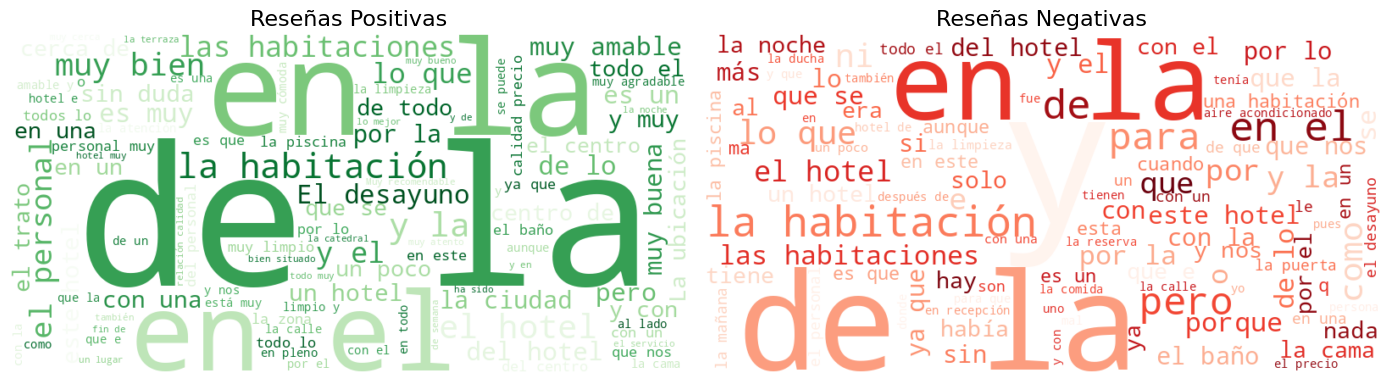

In [ ]:
# Visualiza
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Reseñas Positivas", fontsize=16)

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Reseñas Negativas", fontsize=16)

plt.tight_layout()
plt.show()


### 💡 y si miramos el texto limpio...

In [ ]:
# Agrupa las reseñas por clase
positive_text = " ".join(df_reviews[df_reviews["label"] == 1]["clean_text"].astype(str))
negative_text = " ".join(df_reviews[df_reviews["label"] == 0]["clean_text"].astype(str))

In [ ]:
wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens',
    max_words=100
).generate(positive_text)

In [ ]:
wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds',
    max_words=100
).generate(negative_text)

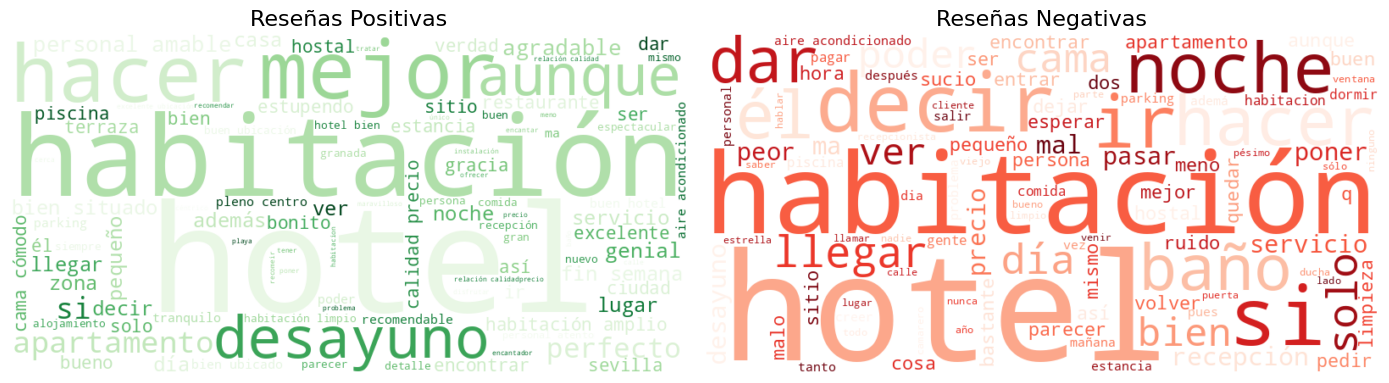

In [ ]:
# Visualiza
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Reseñas Positivas", fontsize=16)

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Reseñas Negativas", fontsize=16)

plt.tight_layout()
plt.show()


In [ ]:
from collections import Counter

In [ ]:
doc = nlp(df_reviews["full_review"].iloc[0])
for token in doc:
    print(f"{token.text:<15} {token.pos_:<10} {token.dep_:<15}")

Excelente       ADJ        ROOT           
y               CCONJ      cc             
personal        ADJ        conj           
amable          ADJ        amod           
.               PUNCT      punct          
Un              DET        det            
hotel           NOUN       ROOT           
muy             ADV        advmod         
bueno           ADJ        amod           
.               PUNCT      punct          
                SPACE      dep            
El              DET        det            
personal        NOUN       nsubj          
fue             AUX        cop            
muy             ADV        advmod         
amable          ADJ        ROOT           
y               CCONJ      cc             
profesional     ADJ        conj           
.               PUNCT      punct          
Nos             PRON       iobj           
gustaban        VERB       ROOT           
desayuno        NOUN       obj            
mucho           ADV        advmod         
también    

In [ ]:
for ent in doc.ents:
    print(ent.text, ent.label_)

Un hotel muy bueno MISC
El habitación cómoda y limpia MISC
Seville LOC
Lo recomiendo !! MISC


In [ ]:
all_pos = []
for doc in nlp.pipe(df_reviews["full_review"][:100], batch_size=20):
    all_pos.extend([token.pos_ for token in doc if not token.is_space])
all_pos

['ADJ',
 'CCONJ',
 'ADJ',
 'ADJ',
 'PUNCT',
 'DET',
 'NOUN',
 'ADV',
 'ADJ',
 'PUNCT',
 'DET',
 'NOUN',
 'AUX',
 'ADV',
 'ADJ',
 'CCONJ',
 'ADJ',
 'PUNCT',
 'PRON',
 'VERB',
 'NOUN',
 'ADV',
 'ADV',
 'PUNCT',
 'DET',
 'NOUN',
 'ADJ',
 'CCONJ',
 'ADJ',
 'PUNCT',
 'VERB',
 'ADP',
 'ADJ',
 'NOUN',
 'ADP',
 'PROPN',
 'ADP',
 'NOUN',
 'PUNCT',
 'PRON',
 'VERB',
 'PUNCT',
 'PUNCT',
 'CCONJ',
 'ADV',
 'VERB',
 'ADV',
 'ADV',
 'ADP',
 'NOUN',
 'INTJ',
 'PUNCT',
 'PROPN',
 'PUNCT',
 'ADV',
 'ADJ',
 'NOUN',
 'ADP',
 'NOUN',
 'ADP',
 'PRON',
 'ADJ',
 'PUNCT',
 'NOUN',
 'PROPN',
 'PROPN',
 'PUNCT',
 'ADV',
 'ADV',
 'ADJ',
 'CCONJ',
 'ADP',
 'DET',
 'PRON',
 'ADJ',
 'ADP',
 'DET',
 'NOUN',
 'ADJ',
 'PUNCT',
 'NOUN',
 'ADP',
 'NOUN',
 'ADJ',
 'PUNCT',
 'NOUN',
 'ADV',
 'ADJ',
 'ADP',
 'VERB',
 'NOUN',
 'PUNCT',
 'NOUN',
 'ADJ',
 'PUNCT',
 'ADV',
 'DET',
 'NOUN',
 'AUX',
 'ADJ',
 'PUNCT',
 'PROPN',
 'ADJ',
 'PUNCT',
 'ADJ',
 'NOUN',
 'PUNCT',
 'DET',
 'NOUN',
 'AUX',
 'SCONJ',
 'DET',
 'ADJ',
 'PUNCT

In [ ]:
pos_counts = Counter(all_pos)
pos_counts

Counter({'ADJ': 788,
         'CCONJ': 346,
         'PUNCT': 966,
         'DET': 890,
         'NOUN': 1392,
         'ADV': 474,
         'AUX': 276,
         'PRON': 290,
         'VERB': 491,
         'ADP': 861,
         'PROPN': 282,
         'INTJ': 7,
         'SCONJ': 131,
         'NUM': 88,
         'SYM': 5})

In [ ]:
pos_counts.items()

dict_items([('ADJ', 788), ('CCONJ', 346), ('PUNCT', 966), ('DET', 890), ('NOUN', 1392), ('ADV', 474), ('AUX', 276), ('PRON', 290), ('VERB', 491), ('ADP', 861), ('PROPN', 282), ('INTJ', 7), ('SCONJ', 131), ('NUM', 88), ('SYM', 5)])

In [ ]:
tags, counts = zip(*sorted(pos_counts.items(), key=lambda x: x[1], reverse=True))

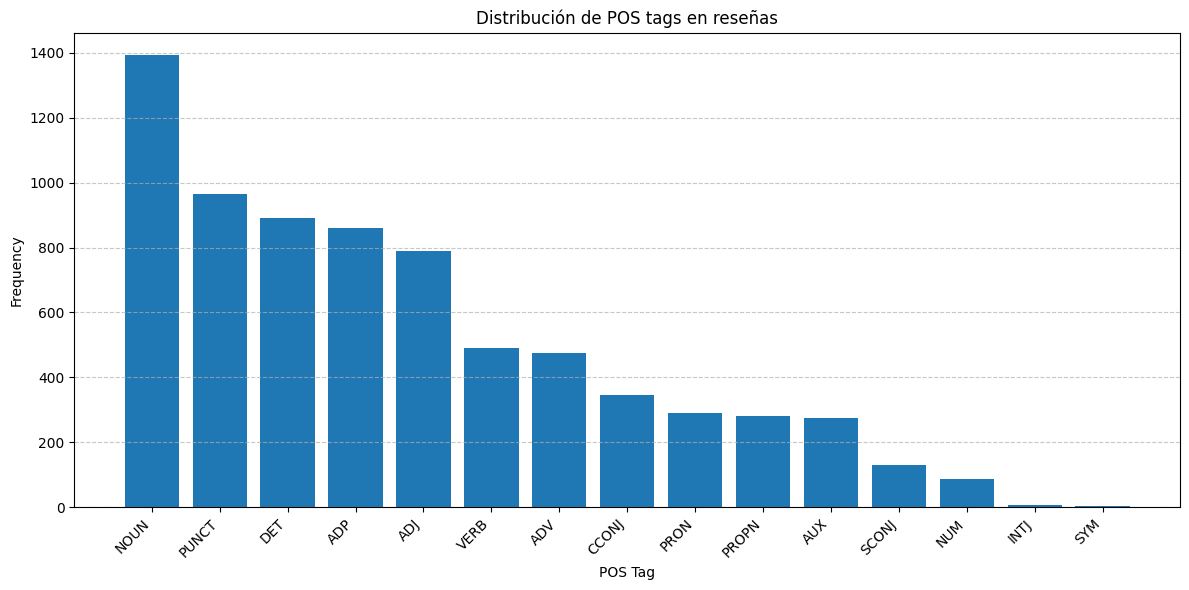

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(tags, counts)
plt.xticks(rotation=45, ha='right')
plt.xlabel("POS Tag")
plt.ylabel("Frequency")
plt.title("Distribución de POS tags en reseñas")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
ent_counter = Counter()

for doc in nlp.pipe(df_reviews["full_review"][:100], batch_size=20):
    ent_counter.update([(ent.text, ent.label_) for ent in doc.ents])

In [ ]:
# Convertir a DataFrame para inspección
ent_df = pd.DataFrame(ent_counter.items(), columns=["Entidad_Label", "Frecuencia"])
ent_df

,Entidad_Label,Frecuencia
0,"(Un hotel muy bueno, MISC)",1
1,"(El habitación cómoda y limpia, MISC)",1
2,"(Seville, LOC)",1
3,"(Lo recomiendo !!, MISC)",1
4,"(Céntrico, LOC)",3
...,...,...
369,"(Espectacular, MISC)",1
370,"(Habitaciones grandes y espaciosas, MISC)",1
371,"(Repitiria, LOC)",1
372,"(El servicio y la atención impecables., MISC)",1


In [ ]:
ent_df[["Entidad", "Etiqueta"]] = pd.DataFrame(ent_df["Entidad_Label"].tolist(), index=ent_df.index)
ent_df

,Entidad_Label,Frecuencia,Entidad,Etiqueta
0,"(Un hotel muy bueno, MISC)",1,Un hotel muy bueno,MISC
1,"(El habitación cómoda y limpia, MISC)",1,El habitación cómoda y limpia,MISC
2,"(Seville, LOC)",1,Seville,LOC
3,"(Lo recomiendo !!, MISC)",1,Lo recomiendo !!,MISC
4,"(Céntrico, LOC)",3,Céntrico,LOC
...,...,...,...,...
369,"(Espectacular, MISC)",1,Espectacular,MISC
370,"(Habitaciones grandes y espaciosas, MISC)",1,Habitaciones grandes y espaciosas,MISC
371,"(Repitiria, LOC)",1,Repitiria,LOC
372,"(El servicio y la atención impecables., MISC)",1,El servicio y la atención impecables.,MISC


In [ ]:
ent_df = ent_df.drop(columns="Entidad_Label")
ent_df

,Frecuencia,Entidad,Etiqueta
0,1,Un hotel muy bueno,MISC
1,1,El habitación cómoda y limpia,MISC
2,1,Seville,LOC
3,1,Lo recomiendo !!,MISC
4,3,Céntrico,LOC
...,...,...,...
369,1,Espectacular,MISC
370,1,Habitaciones grandes y espaciosas,MISC
371,1,Repitiria,LOC
372,1,El servicio y la atención impecables.,MISC


In [ ]:
# Obtener las entidades más frecuentes
top_ents = ent_df.sort_values("Frecuencia", ascending=False).head(15)
top_ents

,Frecuencia,Entidad,Etiqueta
12,42,Sevilla,LOC
144,8,Hotel,MISC
7,6,Habitación,MISC
104,5,Personal,MISC
38,5,Hotel,LOC
166,5,La habitación,MISC
221,4,Buena,LOC
72,4,Estuvimos,LOC
4,3,Céntrico,LOC
121,2,la Giralda,LOC


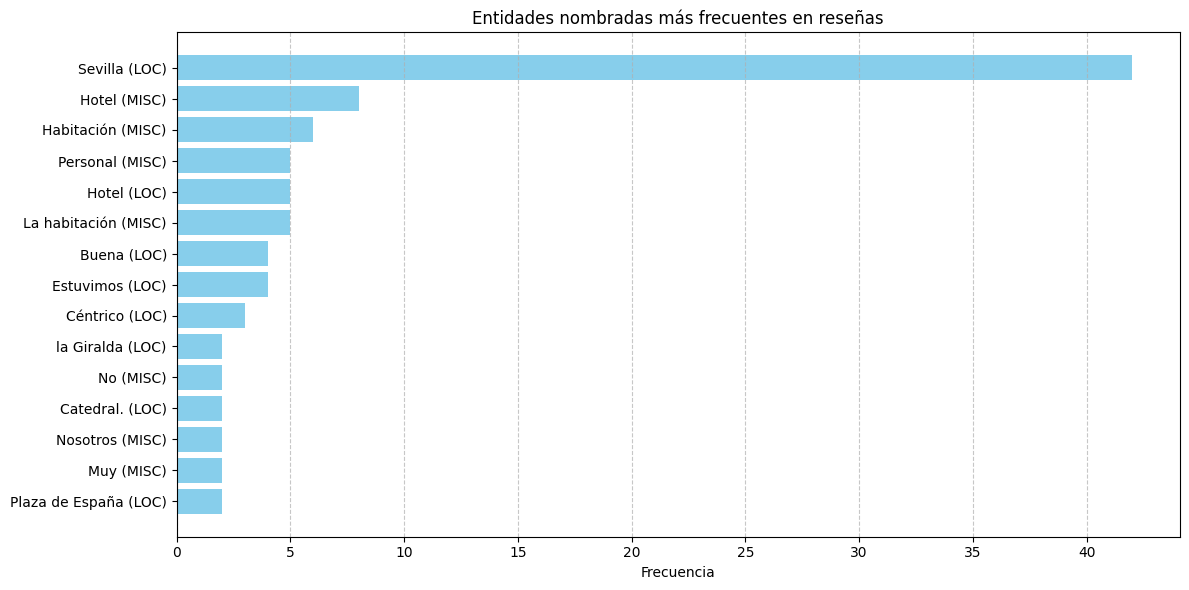

In [ ]:
# Visualizar con gráfico de barras
plt.figure(figsize=(12, 6))
plt.barh(top_ents["Entidad"] + " (" + top_ents["Etiqueta"] + ")", top_ents["Frecuencia"], color='skyblue')
plt.xlabel("Frecuencia")
plt.title("Entidades nombradas más frecuentes en reseñas")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### Ahora sin Stop Words

In [ ]:
all_pos = []
for doc in nlp.pipe(df_reviews["clean_text"][:100], batch_size=20):
    all_pos.extend([token.pos_ for token in doc if not token.is_space])
all_pos

['ADJ',
 'NOUN',
 'ADJ',
 'NOUN',
 'ADJ',
 'NOUN',
 'ADJ',
 'ADJ',
 'VERB',
 'NOUN',
 'NOUN',
 'ADV',
 'ADJ',
 'VERB',
 'ADJ',
 'NOUN',
 'NOUN',
 'ADJ',
 'VERB',
 'NOUN',
 'ADV',
 'NOUN',
 'ADJ',
 'ADJ',
 'NOUN',
 'NOUN',
 'ADJ',
 'NOUN',
 'ADJ',
 'PROPN',
 'ADJ',
 'ADJ',
 'NOUN',
 'ADJ',
 'NOUN',
 'ADJ',
 'ADJ',
 'NOUN',
 'ADJ',
 'VERB',
 'NOUN',
 'NOUN',
 'ADJ',
 'ADV',
 'NOUN',
 'ADJ',
 'NOUN',
 'ADJ',
 'ADJ',
 'NOUN',
 'VERB',
 'ADJ',
 'NOUN',
 'ADJ',
 'ADJ',
 'NOUN',
 'ADJ',
 'ADJ',
 'NOUN',
 'ADJ',
 'NOUN',
 'ADJ',
 'NOUN',
 'ADV',
 'ADJ',
 'NUM',
 'NOUN',
 'ADJ',
 'PROPN',
 'NOUN',
 'ADJ',
 'ADJ',
 'NOUN',
 'ADJ',
 'ADJ',
 'NOUN',
 'ADJ',
 'ADJ',
 'NOUN',
 'ADJ',
 'ADV',
 'PROPN',
 'VERB',
 'ADJ',
 'NOUN',
 'PROPN',
 'PROPN',
 'AUX',
 'ADJ',
 'NOUN',
 'ADJ',
 'ADJ',
 'ADJ',
 'NOUN',
 'ADJ',
 'PROPN',
 'PROPN',
 'VERB',
 'NOUN',
 'VERB',
 'NOUN',
 'ADJ',
 'ADJ',
 'NOUN',
 'NOUN',
 'ADJ',
 'NOUN',
 'ADJ',
 'NOUN',
 'ADJ',
 'ADJ',
 'NOUN',
 'ADJ',
 'NOUN',
 'NOUN',
 'VERB',
 'ADJ',

In [ ]:
pos_counts = Counter(all_pos)
pos_counts

Counter({'ADJ': 962,
         'NOUN': 1162,
         'VERB': 488,
         'ADV': 224,
         'PROPN': 247,
         'NUM': 91,
         'AUX': 56,
         'SCONJ': 35,
         'DET': 48,
         'PRON': 37,
         'ADP': 10,
         'INTJ': 2,
         'PUNCT': 2,
         'CCONJ': 6})

In [ ]:
tags, counts = zip(*sorted(pos_counts.items(), key=lambda x: x[1], reverse=True))

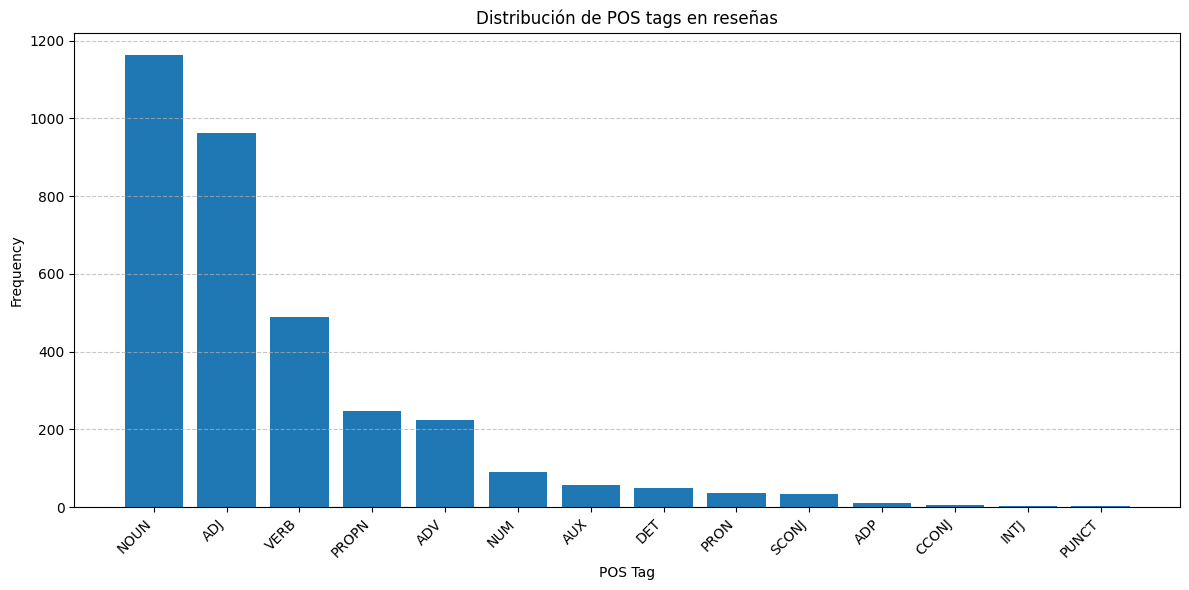

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(tags, counts)
plt.xticks(rotation=45, ha='right')
plt.xlabel("POS Tag")
plt.ylabel("Frequency")
plt.title("Distribución de POS tags en reseñas")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
ent_counter = Counter()

for doc in nlp.pipe(df_reviews["clean_text"][:100], batch_size=20):
    ent_counter.update([(ent.text, ent.label_) for ent in doc.ents])

In [ ]:
# Convertir a DataFrame para inspección
ent_df = pd.DataFrame(ent_counter.items(), columns=["Entidad_Label", "Frecuencia"])
ent_df[["Entidad", "Etiqueta"]] = pd.DataFrame(ent_df["Entidad_Label"].tolist(), index=ent_df.index)
ent_df = ent_df.drop(columns="Entidad_Label")
ent_df

,Frecuencia,Entidad,Etiqueta
0,1,seville,LOC
1,2,hotel,MISC
2,1,wow hotel hermoso buen,MISC
3,1,carrefour express,ORG
4,34,sevilla,LOC
5,1,hotel precioso empiezo,MISC
6,1,puente pellón,LOC
7,1,plaza salvador,LOC
8,1,san pablo,LOC
9,1,h10,MISC


In [ ]:
# Obtener las entidades más frecuentes
top_ents = ent_df.sort_values("Frecuencia", ascending=False).head(15)

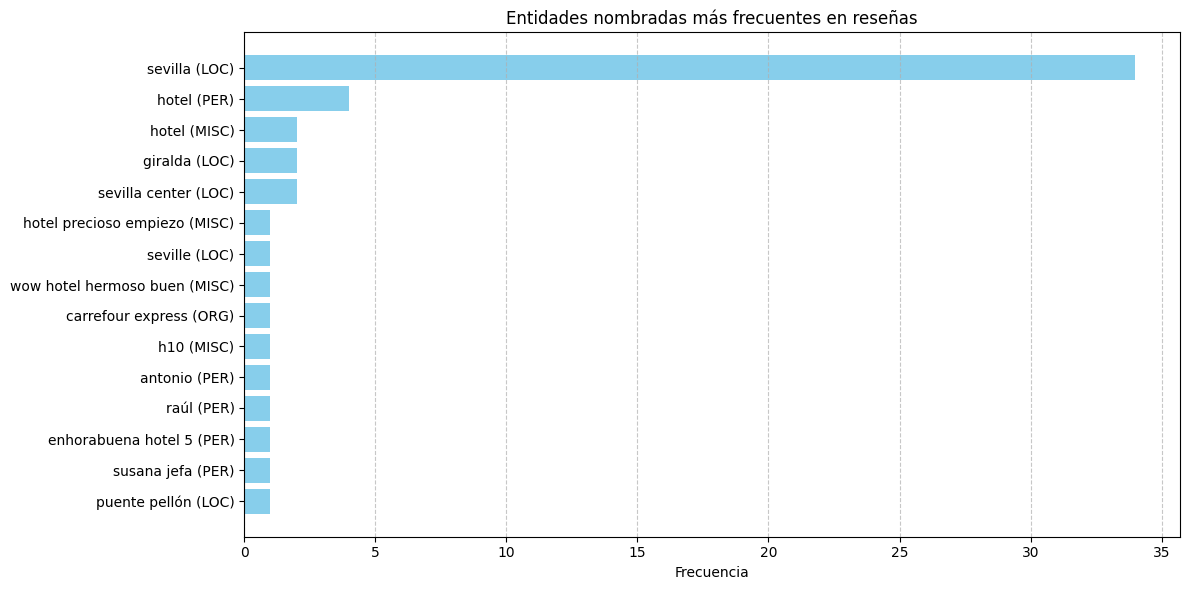

In [ ]:
# Visualizar con gráfico de barras
plt.figure(figsize=(12, 6))
plt.barh(top_ents["Entidad"] + " (" + top_ents["Etiqueta"] + ")", top_ents["Frecuencia"], color='skyblue')
plt.xlabel("Frecuencia")
plt.title("Entidades nombradas más frecuentes en reseñas")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## 5. 🤖 Clasificación de Sentimiento

Se utiliza regresión logística para clasificar las reseñas como positivas o negativas a partir de sus vectores TF-IDF.


In [ ]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 116892 stored elements and shape (18172, 30)>

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
X_train, X_test, y_train, y_test, idx_train, idx_test  = train_test_split(X, df_reviews["label"],  df_reviews.index, test_size=0.3, random_state=42)

clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.39      0.48       791
           1       0.90      0.96      0.93      4661

    accuracy                           0.88      5452
   macro avg       0.76      0.67      0.70      5452
weighted avg       0.86      0.88      0.86      5452



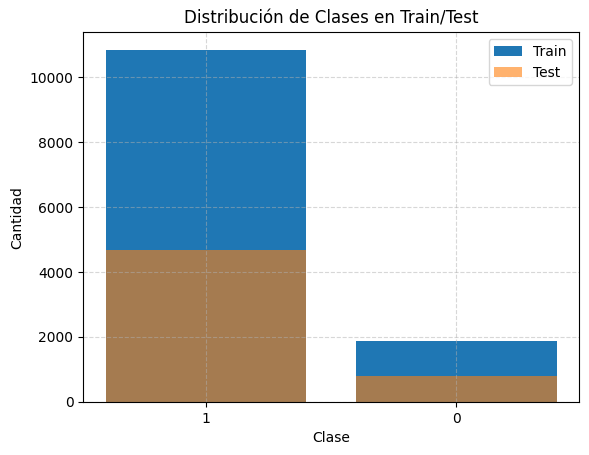

In [ ]:
y_train_counts = y_train.value_counts()
y_test_counts = y_test.value_counts()

# Visualización
plt.bar(y_train_counts.index.astype(str), y_train_counts.values, label="Train")
plt.bar(y_test_counts.index.astype(str), y_test_counts.values, alpha=0.6, label="Test")
plt.title("Distribución de Clases en Train/Test")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

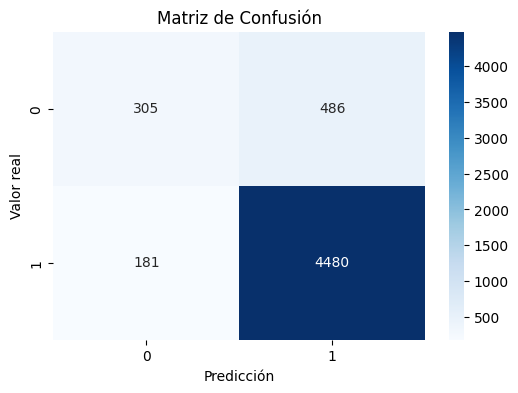

In [ ]:
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

# Visualizar matriz
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")
plt.show()


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.39      0.48       791
           1       0.90      0.96      0.93      4661

    accuracy                           0.88      5452
   macro avg       0.76      0.67      0.70      5452
weighted avg       0.86      0.88      0.86      5452



### 🔍 Evaluación del Modelo Binario (Clases: 0 = Negativa, 1 = Positiva)

1. **Precisión general aceptable**:
   - El modelo alcanzó una **exactitud (accuracy) del 88%**, lo cual es muy bueno en términos generales.
   - La clase positiva (`1`) tiene una alta **precisión (0.90)** y **recall (0.93)**, lo que significa que la mayoría de las reseñas positivas están siendo correctamente identificadas.

2. **Desempeño en clase negativa (`0`) aún limitado**:
   - El modelo tiene una **precisión de 0.63** para detectar reseñas negativas, pero su **recall es bajo (0.39)**.
   - Esto indica que cuando predice negativo, usualmente acierta, pero falla al encontrar muchos de los verdaderos casos negativos (muchos son clasificados como positivos).

3. **Medidas agregadas**:
   - El **f1-score ponderado (weighted avg)** es de **0.86**, lo que indica un rendimiento sólido, especialmente porque la clase `1` es mayoritaria.
   - El **macro promedio** (0.70) es más conservador porque penaliza el bajo recall en la clase minoritaria.

---

### ✅ Recomendaciones

1. **Revisar balance de clases**:
   - Aunque ya no está la clase `3`, aún hay un fuerte desbalance: la clase positiva (`1`) es 6 veces más frecuente que la negativa (`0`).
   - Puedes considerar técnicas como:
     - *Oversampling* (por ejemplo con `SMOTE`).
     - *Class weights* en el modelo: `LogisticRegression(class_weight="balanced")`.

2. **Análisis de errores**:
   - Examina manualmente algunas de las reseñas negativas mal clasificadas como positivas.
   - Esto puede ayudarte a entender si hay patrones lingüísticos que el modelo no está captando (e.g. sarcasmo, negaciones, adjetivos ambiguos).

3. **Mejorar representación del texto**:
   - Probar TF-IDF con **n-gramas** (`ngram_range=(1,2)`).
   - Usar representaciones contextuales como `spaCy`, `Word2Vec` o incluso `BERT` si necesitas mayor precisión.

4. **Matriz de confusión**:
   - Es útil visualizar cómo se están cometiendo los errores para ajustar el umbral de decisión si fuese necesario (por ejemplo, con curvas ROC o precision-recall).

---

## 🧮 Métricas de Evaluación del Modelo

A continuación se explican las principales métricas usadas para evaluar el desempeño de modelos de clasificación:

### 📌 1. **Precisión (Precision)**
- Indica el porcentaje de predicciones positivas que realmente son correctas.
- Fórmula:  
  $$
  \text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}
  $$
- Alta precisión significa pocas falsas alarmas.

### 📌 2. **Exhaustividad / Cobertura (Recall)**
- También llamado sensibilidad o tasa de verdaderos positivos.
- Mide el porcentaje de verdaderos positivos que fueron correctamente identificados.
- Fórmula:  
  $$
  \text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}
  $$
- Alto recall significa pocos casos positivos omitidos.

### 📌 3. **F1-Score**
- Media armónica entre precisión y recall.
- Se usa cuando se quiere un balance entre ambos.
- Fórmula:  
  $$
  \text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
  $$

### 📌 4. **Exactitud (Accuracy)**
- Proporción total de predicciones correctas (positivas y negativas).
- Fórmula:  
  $$
  \text{Accuracy} = \frac{\text{Total de aciertos}}{\text{Total de ejemplos}}
  $$
- Puede ser engañosa si las clases están desbalanceadas.

### 📌 5. **Macro Promedio (Macro Avg)**
- Calcula la métrica (precision, recall, f1) para cada clase y luego promedia sin ponderar por frecuencia.
- Da igual peso a todas las clases, aunque estén desbalanceadas.

### 📌 6. **Promedio Ponderado (Weighted Avg)**
- Calcula la métrica por clase, pero pondera cada valor según el número de muestras de esa clase.
- Más representativo en conjuntos de datos desbalanceados.


### 🎲 Ejemplo

In [ ]:
import random

In [ ]:
# Elegir un índice del subconjunto de test
idx = random.choice(idx_test)
idx

np.int64(14246)

In [ ]:
# Extraer texto original y etiqueta real
texto_original = df_reviews.loc[idx, 'review_text']
etiqueta_real = df_reviews.loc[idx, 'label']
print(texto_original,etiqueta_real)

Pasamos un fin de semana excelente. La casa se encuentra en un paraje precioso, ideal para hacer rutas. El camino por el río hasta el pueblo es una maravilla. La habitación es sencilla pero muy cómoda. El único pero es que no tiene aire acondicionado y en plena ola de calor el ventilador se quedaba un poco corto. Bañarte en la piscina bajo las estrellas es maravilloso. También te puedes tomar una copa muy agradable. El acceso es complicado pero Gero os llevará y traerá del pueblo cada vez que queráis. El trato es excelente. Relación calidad precio inigualable.  1


In [ ]:
# Preprocesar y vectorizar
texto_limpio = preprocess(texto_original)
X_single = vectorizer.transform([texto_limpio])

In [ ]:
clf.predict(X_single)

array([1])

In [ ]:
clf.predict_proba(X_single)

array([[0.00389286, 0.99610714]])

In [ ]:
# Predecir clase y probabilidad
pred_clase = clf.predict(X_single)[0]
pred_proba = clf.predict_proba(X_single)[0][pred_clase]

In [ ]:
# Mostrar resultados
print("📝 Reseña original:\n", texto_original)
print("\n✅ Clase real:", etiqueta_real)
print("🔮 Predicción:", pred_clase, f"(Probabilidad: {pred_proba:.2f})")

📝 Reseña original:
 Pasamos un fin de semana excelente. La casa se encuentra en un paraje precioso, ideal para hacer rutas. El camino por el río hasta el pueblo es una maravilla. La habitación es sencilla pero muy cómoda. El único pero es que no tiene aire acondicionado y en plena ola de calor el ventilador se quedaba un poco corto. Bañarte en la piscina bajo las estrellas es maravilloso. También te puedes tomar una copa muy agradable. El acceso es complicado pero Gero os llevará y traerá del pueblo cada vez que queráis. El trato es excelente. Relación calidad precio inigualable. 

✅ Clase real: 1
🔮 Predicción: 1 (Probabilidad: 1.00)


## 6. 🎯 Visualización de Resultados

En esta sección se analizan las palabras más influyentes para cada clase del modelo entrenado. Esto permite interpretar qué términos están más asociados a reseñas positivas o negativas.


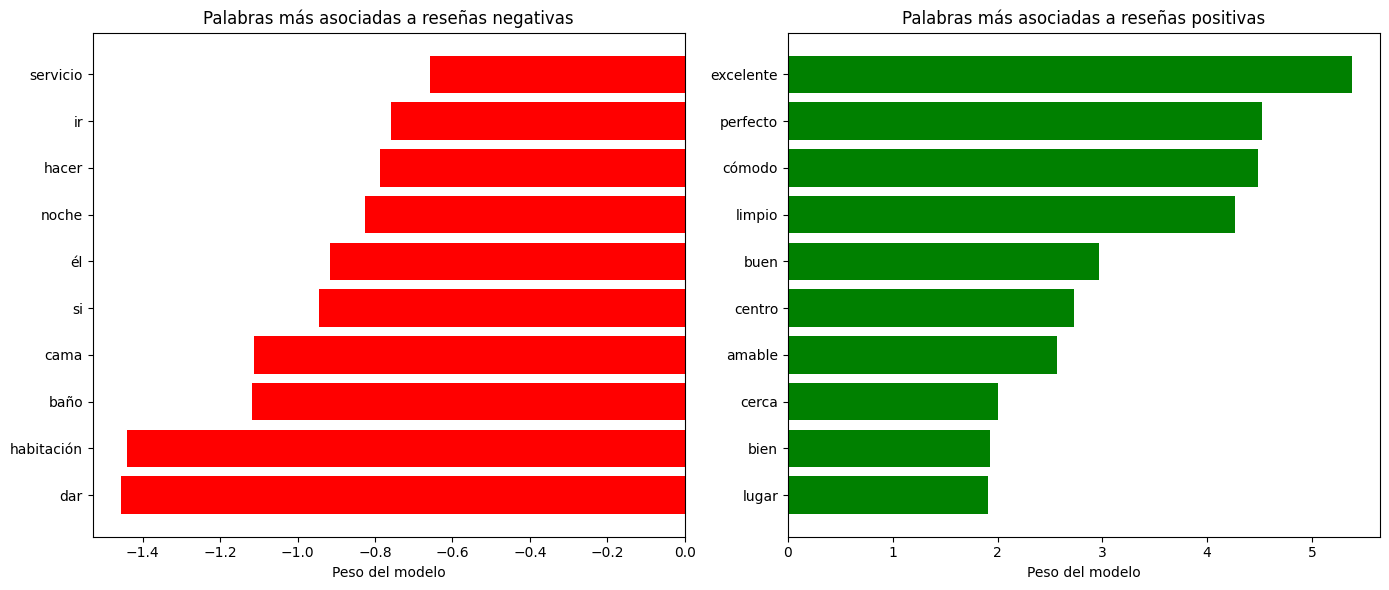

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extraer coeficientes y términos
coefs = clf.coef_[0]
terms = vectorizer.get_feature_names_out()

# Obtener los términos más importantes para cada clase
top_n = 10
top_pos = np.argsort(coefs)[-top_n:]
top_neg = np.argsort(coefs)[:top_n]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.barh(range(top_n), coefs[top_neg], align="center", color="red")
plt.yticks(range(top_n), [terms[i] for i in top_neg])
plt.title("Palabras más asociadas a reseñas negativas")
plt.xlabel("Peso del modelo")

plt.subplot(1, 2, 2)
plt.barh(range(top_n), coefs[top_pos], align="center", color="green")
plt.yticks(range(top_n), [terms[i] for i in top_pos])
plt.title("Palabras más asociadas a reseñas positivas")
plt.xlabel("Peso del modelo")

plt.tight_layout()
plt.show()


## 🔍 Interpretación de las palabras más relevantes por clase

El modelo de regresión logística asigna **pesos** (coeficientes) a cada palabra según su influencia en la predicción. Estos pesos nos permiten identificar cuáles términos **empujan la predicción hacia la clase positiva o negativa**:

### 📈 Palabras asociadas a reseñas positivas (coeficientes positivos)
- Palabras como `excelente`, `limpio`, `buen`, `amable`, `ubicación`, `bien` o `lugar` aparecen como los términos más positivos.
- Esto tiene sentido semánticamente, ya que estos adjetivos y sustantivos suelen expresar satisfacción, comodidad y una buena experiencia general.

### 📉 Palabras asociadas a reseñas negativas (coeficientes negativos)
- Términos como `habitación`, `noche`, `baño`, `precio`, `hotel`, `habitaciones` tienen pesos negativos, lo que significa que su aparición está correlacionada con reseñas clasificadas como negativas.
- Esto sugiere que **cuando estas palabras aparecen en el texto, es más probable que el sentimiento general sea negativo**. Por ejemplo, si un huésped menciona mucho el "baño" o el "trato", podría estar describiendo fallas o quejas.

### 📉 Palabras asociadas a reseñas negativas (coeficientes positivos)
-  Palabras con pesos también positivos pero graficadas en la sección "negativa" como `personal`, `trato` y `desayuno`. En realidad, también están empujando la predicción hacia la clase 1 (positiva). El gráfico no está separando por signo, sino simplemente por orden creciente/decreciente de los coeficientes.


### ✅ Conclusión
- El modelo ha aprendido **patrones coherentes con el lenguaje humano**: palabras altamente valorativas y positivas tienen coeficientes altos, mientras que términos más neutrales pero frecuentemente usados en quejas aparecen del lado negativo.
- Este tipo de análisis no solo es útil para interpretar el modelo, sino también para:
  - **Diseñar estrategias de mejora** en hoteles (si ciertas palabras negativas son frecuentes).
  - **Retroalimentar a equipos de atención al cliente**.
  - **Construir dashboards explicativos** para usuarios no técnicos.



---

## ✅ Conclusiones

- El preprocesamiento textual es crucial para mejorar la calidad de los datos de entrada.
- TF-IDF ofrece una forma sencilla y eficaz de representar texto numéricamente.
- Modelos simples como la regresión logística pueden ofrecer buenos resultados iniciales para clasificación binaria de sentimiento.

🔁 Próximos pasos pueden incluir el uso de embeddings (Word2Vec, BERT), modelado temático o análisis por ubicación.



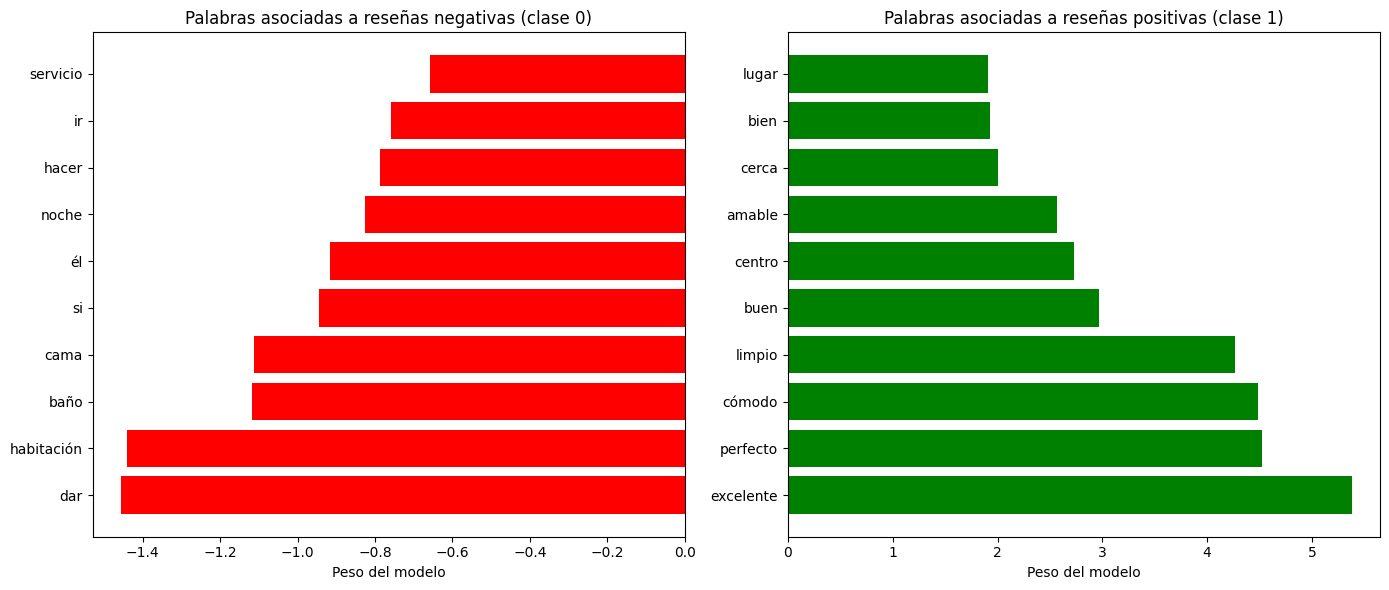

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Asegúrate de tener df_weights correctamente definido
df_weights = pd.DataFrame({'word': terms, 'coef': coefs})

# Filtrar solo palabras relevantes por clase
top_n = 10
top_neg = df_weights[df_weights["coef"] < 0].sort_values(by="coef", ascending=True).head(top_n)
top_pos = df_weights[df_weights["coef"] > 0].sort_values(by="coef", ascending=False).head(top_n)

# Visualización
plt.figure(figsize=(14, 6))

# Negativas
plt.subplot(1, 2, 1)
plt.barh(top_neg['word'], top_neg['coef'], color='red')
plt.title("Palabras asociadas a reseñas negativas (clase 0)")
plt.xlabel("Peso del modelo")

# Positivas
plt.subplot(1, 2, 2)
plt.barh(top_pos['word'], top_pos['coef'], color='green')
plt.title("Palabras asociadas a reseñas positivas (clase 1)")
plt.xlabel("Peso del modelo")

plt.tight_layout()
plt.show()
